<a href="https://colab.research.google.com/github/rivalrashid/MLpipeline/blob/main/ML_milestone4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload train_data.xls only

train = pd.read_csv('train_data.xls')

X_train = train.drop('Y', axis=1)
y_train = train['Y']

X_train.columns = X_train.columns.str.replace(r'[\[\]<>&()]', '_', regex=True).str.strip('_')

print(f'Train set: {X_train.shape}')
print(f'Class distribution:\n{y_train.value_counts()}')
print('\nTest set is reserved for Milestone 5.')

Saving test_data.xls to test_data (1).xls
Saving train_data.xls to train_data (1).xls
Train set: (10147, 20)
Class distribution:
Y
1    5768
0    4379
Name: count, dtype: int64

Test set is reserved for Milestone 5.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_val_scores = []
base_gaps       = []

print('--- BASELINE MODEL (M3 Config) ---')
for fold, (ti, vi) in enumerate(cv.split(X_train, y_train)):
    m = XGBClassifier(
        learning_rate=0.005,  n_estimators=5000,
        max_depth=8,          reg_alpha=0.1,
        reg_lambda=1.0,       subsample=0.8,
        colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1,            early_stopping_rounds=50,
        eval_metric='logloss', random_state=42
    )
    m.fit(X_train.iloc[ti], y_train.iloc[ti],
          eval_set=[(X_train.iloc[vi], y_train.iloc[vi])], verbose=False)

    tr_acc  = accuracy_score(y_train.iloc[ti], m.predict(X_train.iloc[ti]))
    val_acc = accuracy_score(y_train.iloc[vi], m.predict(X_train.iloc[vi]))
    gap     = tr_acc - val_acc

    base_val_scores.append(val_acc)
    base_gaps.append(gap)
    print(f'  Fold {fold+1}: Train={tr_acc:.4f} | Val={val_acc:.4f} | Gap={gap:.4f}')

print(f'\nBaseline CV Val Mean : {np.mean(base_val_scores):.4f} | Std: {np.std(base_val_scores):.4f}')
print(f'Baseline Avg Gap     : {np.mean(base_gaps):.4f}  <-- overfitting')


--- BASELINE MODEL (M3 Config) ---
  Fold 1: Train=0.8746 | Val=0.7345 | Gap=0.1401
  Fold 2: Train=0.8779 | Val=0.7350 | Gap=0.1429
  Fold 3: Train=0.8814 | Val=0.7388 | Gap=0.1426
  Fold 4: Train=0.8816 | Val=0.7541 | Gap=0.1276
  Fold 5: Train=0.8846 | Val=0.7482 | Gap=0.1364

Baseline CV Val Mean : 0.7421 | Std: 0.0077
Baseline Avg Gap     : 0.1379  <-- overfitting


In [ ]:
opt_val_scores = []
opt_gaps       = []

print('--- OPTIMIZED MODEL (M4 Config) ---')
for fold, (ti, vi) in enumerate(cv.split(X_train, y_train)):
    m = XGBClassifier(
        learning_rate=0.01,   n_estimators=500,
        max_depth=4,          reg_alpha=0.5,
        reg_lambda=2.0,       subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        gamma=0.1,            early_stopping_rounds=30,
        eval_metric='logloss', random_state=42
    )
    m.fit(X_train.iloc[ti], y_train.iloc[ti],
          eval_set=[(X_train.iloc[vi], y_train.iloc[vi])], verbose=False)

    tr_acc  = accuracy_score(y_train.iloc[ti], m.predict(X_train.iloc[ti]))
    val_acc = accuracy_score(y_train.iloc[vi], m.predict(X_train.iloc[vi]))
    gap     = tr_acc - val_acc

    opt_val_scores.append(val_acc)
    opt_gaps.append(gap)
    print(f'  Fold {fold+1}: Train={tr_acc:.4f} | Val={val_acc:.4f} | Gap={gap:.4f}')

print(f'\nOptimized CV Val Mean : {np.mean(opt_val_scores):.4f} | Std: {np.std(opt_val_scores):.4f}')
print(f'Optimized Avg Gap     : {np.mean(opt_gaps):.4f}  <-- reduced')

gap_reduction = (np.mean(base_gaps) - np.mean(opt_gaps)) / np.mean(base_gaps) * 100
print(f'\nGap Reduction: {gap_reduction:.1f}%')


--- OPTIMIZED MODEL (M4 Config) ---
  Fold 1: Train=0.7229 | Val=0.7059 | Gap=0.0170
  Fold 2: Train=0.7223 | Val=0.7005 | Gap=0.0218
  Fold 3: Train=0.7219 | Val=0.7058 | Gap=0.0161
  Fold 4: Train=0.7233 | Val=0.7082 | Gap=0.0151
  Fold 5: Train=0.7199 | Val=0.7112 | Gap=0.0087

Optimized CV Val Mean : 0.7063 | Std: 0.0035
Optimized Avg Gap     : 0.0157  <-- reduced

Gap Reduction: 88.6%


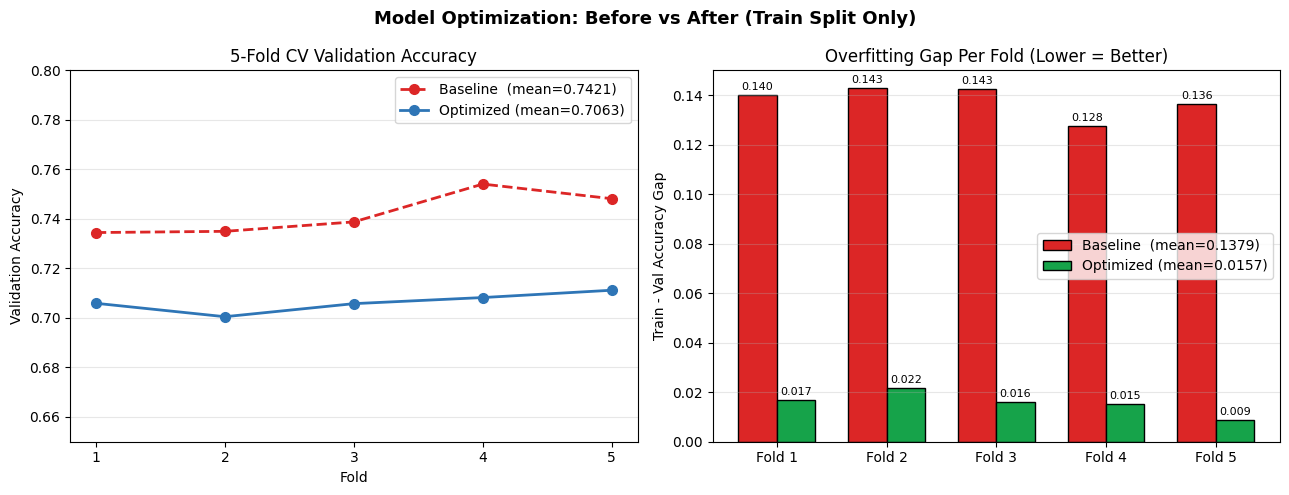


--- SUMMARY ---
Baseline  CV Val: 0.7421 | Avg Gap: 0.1379
Optimized CV Val: 0.7063 | Avg Gap: 0.0157
Gap Reduction   : 88.6%

Note: Test set untouched — reserved for Milestone 5.


In [ ]:
folds = list(range(1, 6))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Val accuracy per fold
ax1 = axes[0]
ax1.plot(folds, base_val_scores, 'o--', color='#DC2626', label=f'Baseline  (mean={np.mean(base_val_scores):.4f})', linewidth=2, markersize=7)
ax1.plot(folds, opt_val_scores,  'o-',  color='#2E75B6', label=f'Optimized (mean={np.mean(opt_val_scores):.4f})',  linewidth=2, markersize=7)
ax1.set_xticks(folds)
ax1.set_xlabel('Fold')
ax1.set_ylabel('Validation Accuracy')
ax1.set_title('5-Fold CV Validation Accuracy')
ax1.set_ylim(0.65, 0.80)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Overfitting gap per fold
ax2 = axes[1]
x  = np.arange(5)
w  = 0.35
b1 = ax2.bar(x - w/2, base_gaps, w, label=f'Baseline  (mean={np.mean(base_gaps):.4f})', color='#DC2626', edgecolor='black')
b2 = ax2.bar(x + w/2, opt_gaps,  w, label=f'Optimized (mean={np.mean(opt_gaps):.4f})',  color='#16A34A', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Fold {i}' for i in folds])
ax2.set_ylabel('Train - Val Accuracy Gap')
ax2.set_title('Overfitting Gap Per Fold (Lower = Better)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar in b1: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in b2: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.suptitle('Model Optimization: Before vs After (Train Split Only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n--- SUMMARY ---')
print(f'Baseline  CV Val: {np.mean(base_val_scores):.4f} | Avg Gap: {np.mean(base_gaps):.4f}')
print(f'Optimized CV Val: {np.mean(opt_val_scores):.4f} | Avg Gap: {np.mean(opt_gaps):.4f}')
print(f'Gap Reduction   : {gap_reduction:.1f}%')
print(f'\nNote: Test set untouched — reserved for Milestone 5.')
